# 📊 Earnings Quality Analysis & Interactive Tool

## Overview

This project investigates earnings quality in the food and beverage industry, a sector typically considered stable.

Using firm-level financial data, it develops an interactive Streamlit tool to examine variations in earnings quality and assess whether revenue growth is a reliable indicator of financial risk.

Traditional analysis often compares “growth” and “mature” firms, assuming that growth firms may exhibit lower earnings quality. However, this study finds that such classification does not adequately explain these differences.

Instead, substantial variation exists across individual firms, even within the same category, highlighting the importance of firm-level analysis over broad group comparisons.

To address this, the project extends beyond static analysis by transforming the results into an interactive tool, enabling users to explore company-specific financial performance and gain deeper insights.

## Target Users

The target users of this analysis are investors and financial analysts who aim to evaluate firm performance beyond simple growth metrics and identify potential financial risks.

This tool helps users move from aggregate comparisons to firm-level insights, enabling more informed decision-making.

In [1]:
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## Data Extraction

Financial data is obtained from the WRDS Compustat database.

Data were accessed in April 2026.

The sample includes 10 firms in the food and beverage industry and covers the period 2020–2024 to ensure comparability across firms.

The following key variables are used:
- Net Income (ni)
- Operating Cash Flow (oancf)
- Total Assets (at)
- Revenue (revt)

In [4]:
print("Connecting to WRDS...")
conn = wrds.Connection()

tickers = ('KO', 'PEP', 'MDLZ', 'GIS', 'KHC', 'MNST', 'BYND', 'OTLY', 'CELH', 'SMPL')

sql_query = f"""
SELECT gvkey, tic, fyear, ni, oancf, at, revt
FROM comp.funda
WHERE tic IN {tickers}
AND fyear BETWEEN 2020 AND 2024
AND indfmt='INDL' AND datafmt='STD' AND popsrc='D' AND consol='C'
"""

raw_data = conn.raw_sql(sql_query)
print("Data extracted successfully.")
display(raw_data.head())
# ✅ Check 1: Tickers coverage
print("Tickers found in dataset:")
print(sorted(raw_data['tic'].unique()))

# ✅ Check 2: Year coverage by company
coverage = raw_data.groupby('tic')['fyear'].agg(['min','max','count'])
print("Coverage by ticker:")
display(coverage)

Connecting to WRDS...


Enter your WRDS username [Administrator]: jiahuizhang24
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\Administrator\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Data extracted successfully.


,gvkey,tic,fyear,ni,oancf,at,revt
0,034447,BYND,2020,-52.7520,-39.9950,468.0060,406.7850
1,034447,BYND,2021,-182.1050,-301.3700,"1,379.3990",464.7000
2,034447,BYND,2022,-366.1370,-320.2440,"1,062.2240",418.9330
3,034447,BYND,2023,-338.1440,-107.8250,774.4500,343.3760
4,034447,BYND,2024,-160.2780,-98.8130,678.1460,326.4520


Tickers found in dataset:
['BYND', 'CELH', 'GIS', 'KHC', 'KO', 'MDLZ', 'MNST', 'OTLY', 'PEP', 'SMPL']
Coverage by ticker:


,min,max,count
tic,,,
BYND,2020,2024,5
CELH,2020,2024,5
GIS,2020,2024,5
KHC,2020,2024,5
KO,2020,2024,5
MDLZ,2020,2024,5
MNST,2020,2024,5
OTLY,2020,2024,5
PEP,2020,2024,5


## Data Cleaning and Transformation

The dataset is cleaned by removing missing values and constructing key financial indicators.

### Earnings Quality Measures

- Accruals = Net Income − Operating Cash Flow  
- Accrual Ratio = Accruals / Total Assets  

A higher accrual ratio suggests that earnings are less supported by actual cash flows, indicating lower earnings quality.

In [5]:
df = raw_data.dropna().copy()

df['Accruals'] = df['ni'] - df['oancf']
df['Accrual_Ratio'] = df['Accruals'] / df['at']
df['Rev_Growth'] = df.groupby('tic')['revt'].pct_change()

df = df.sort_values(['tic', 'fyear'])

print("Core financial variables:")
display(df[['tic', 'fyear', 'ni', 'oancf', 'at', 'revt']].head())

Core financial variables:


,tic,fyear,ni,oancf,at,revt
0,BYND,2020,-52.7520,-39.9950,468.0060,406.7850
1,BYND,2021,-182.1050,-301.3700,"1,379.3990",464.7000
2,BYND,2022,-366.1370,-320.2440,"1,062.2240",418.9330
3,BYND,2023,-338.1440,-107.8250,774.4500,343.3760
4,BYND,2024,-160.2780,-98.8130,678.1460,326.4520


## Firm Classification

Firms are classified into two groups:

- Mature firms: Coca-Cola, PepsiCo, Mondelez, General Mills, Kraft Heinz  
- Growth firms: Monster Beverage, Beyond Meat, Oatly, Celsius Holdings, Simply Good Foods  

These classifications are based on general industry characteristics, where mature firms are large, established companies with stable growth, while growth firms are relatively newer or exhibit higher revenue growth potential.

This classification provides a starting point for comparison, which is later evaluated against data-driven results.

In [6]:
mature = ['KO', 'PEP', 'MDLZ', 'GIS', 'KHC']
df['Type'] = df['tic'].apply(lambda x: 'Mature' if x in mature else 'Growth')

## Descriptive Analysis

Summary statistics are used to compare revenue growth and earnings quality across groups.

In [7]:
summary = df.groupby('Type')[['Accrual_Ratio', 'Rev_Growth']].mean()
display(summary)

,Accrual_Ratio,Rev_Growth
Type,,
Growth,-0.0322,0.2589
Mature,-0.0180,0.0525


Although growth firms have significantly higher revenue growth, the difference in accrual ratios between the two groups is relatively small. 

This suggests that revenue growth alone does not strongly explain earnings quality differences.

## Firm-Level Analysis (Key Insight)

To further investigate the results, firm-level statistics are calculated.

This allows us to examine whether differences exist across individual companies rather than relying solely on group-level averages.

In [8]:
firm_summary = (
    df.groupby(['tic', 'Type'], as_index=False)
      .agg(
          Avg_Accrual_Ratio=('Accrual_Ratio', 'mean'),
          Avg_Rev_Growth=('Rev_Growth', 'mean'),
          Avg_NI=('ni', 'mean'),
          Avg_OCF=('oancf', 'mean')
      )
      .sort_values('Avg_Accrual_Ratio')
)

display(firm_summary)

,tic,Type,Avg_Accrual_Ratio,Avg_Rev_Growth,Avg_NI,Avg_OCF
7,OTLY,Growth,-0.0915,0.1964,-256.8288,-161.4280
0,BYND,Growth,-0.0744,-0.0464,-219.8832,-173.6494
8,PEP,Mature,-0.0349,0.0698,"8,460.0000","11,797.8000"
3,KHC,Mature,-0.0245,-0.0031,"1,866.0000","4,184.4000"
9,SMPL,Growth,-0.0183,0.1321,97.5952,137.6940
2,GIS,Mature,-0.0180,0.0188,"2,486.5600","3,059.7400"
4,KO,Mature,-0.0082,0.0940,"9,681.0000","10,378.2000"
5,MDLZ,Mature,-0.0043,0.0831,"4,028.4000","4,327.4000"
6,MNST,Growth,0.0018,0.1302,"1,423.7458","1,410.7778"
1,CELH,Growth,0.0213,0.8822,39.4108,83.8214


This firm-level analysis reveals substantial variation in earnings quality across individual firms, even within the same group.

For example, some growth firms (e.g., Oatly and Beyond Meat) exhibit strong earnings quality, while others (e.g., Celsius) show relatively weaker performance.

This suggests that firm-level differences are more important than simple growth classification when evaluating earnings quality.

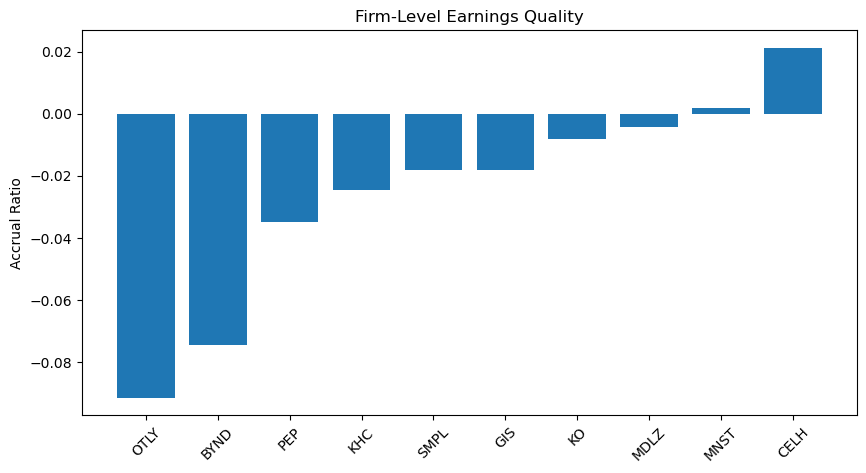

In [9]:
plt.figure(figsize=(10,5))
plt.bar(firm_summary['tic'], firm_summary['Avg_Accrual_Ratio'])
plt.title("Firm-Level Earnings Quality")
plt.ylabel("Accrual Ratio")
plt.xticks(rotation=45)
plt.show()

This firm-level analysis shows that earnings quality varies significantly across individual companies, even within the same group.

This suggests that firm-level differences are more important than simple growth classification.

## Statistical Test

A t-test is conducted to examine whether the difference in accrual ratios between growth and mature firms is statistically significant.

In [11]:
growth = df[df['Type']=='Growth']['Accrual_Ratio'].dropna()
mature_group = df[df['Type']=='Mature']['Accrual_Ratio'].dropna()

t_stat, p_value = stats.ttest_ind(growth, mature_group, equal_var=False)

print("p-value:", p_value)

p-value: 0.5556620457685701


The test result shows that the difference between the two groups is not statistically significant.

This reinforces that group classification alone cannot explain earnings quality.

## Visualization: Revenue Growth vs Earnings Quality

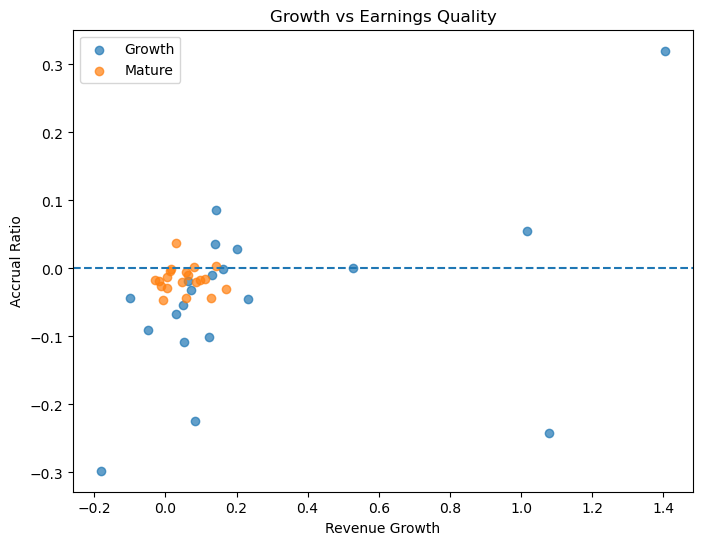

In [12]:
plot_df = df.dropna(subset=['Rev_Growth','Accrual_Ratio'])

plt.figure(figsize=(8,6))

for t in plot_df['Type'].unique():
    subset = plot_df[plot_df['Type']==t]
    plt.scatter(subset['Rev_Growth'], subset['Accrual_Ratio'], label=t, alpha=0.7)

plt.axhline(0, linestyle='--')
plt.xlabel("Revenue Growth")
plt.ylabel("Accrual Ratio")
plt.title("Growth vs Earnings Quality")
plt.legend()
plt.show()

The scatter plot shows no clear linear relationship between revenue growth and accrual ratio.

This suggests that revenue growth is not a reliable standalone indicator of earnings quality.

Investors should therefore avoid relying solely on growth metrics when evaluating financial performance.

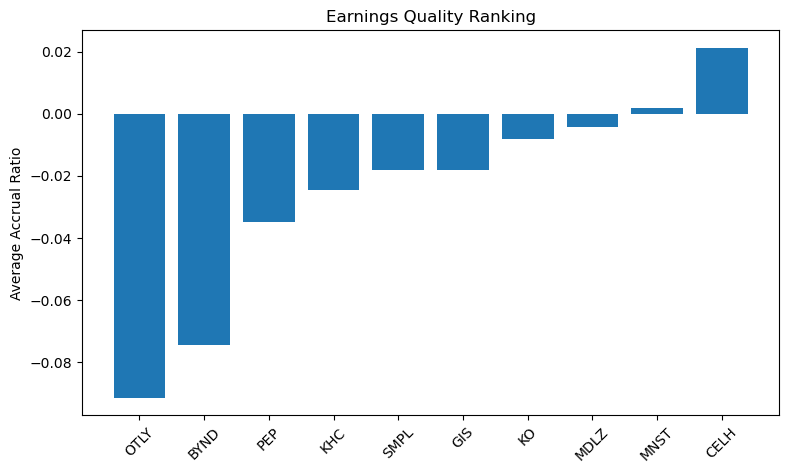

In [13]:
plt.figure(figsize=(9,5))
plt.bar(firm_summary['tic'], firm_summary['Avg_Accrual_Ratio'])
plt.title("Earnings Quality Ranking")
plt.ylabel("Average Accrual Ratio")
plt.xticks(rotation=45)
plt.show()

The ranking further highlights that earnings quality varies across individual firms, reinforcing the importance of firm-level analysis.

In [14]:
df.to_csv("cleaned_data.csv", index=False)
firm_summary.to_csv("firm_summary.csv", index=False)

conn.close()

## Key Findings

The analysis shows that there is no strong or consistent relationship between revenue growth and earnings quality.

Although growth firms exhibit higher revenue growth, they do not systematically have lower earnings quality.

Instead, firm-level differences are more important than simple growth classifications.

These findings justify the development of an interactive tool that allows users to explore company-level financial performance in detail, rather than relying on aggregate comparisons.